# X-Trend Final Rigorous Comparison

This notebook runs the final rigorous 21-ETF comparison with:
- `BaselineDMN` (temporal-block baseline)
- `XTrend`
- `XTrendCS`
- `XTrendLL_A4` (causal LL with Bennett + ranking + delta)
- `XTrendCSLL_A4` (causal CS + causal LL A4)

It assumes the official GitHub repo includes:
- causal `CrossSectionBlock` in `components.py`
- `LagAwarePeerBlock` in `lag_blocks.py`
- `XTrendLLAblation` and `XTrendCSLLAblation` in `x_trend_cross_section.py`
- `lead_lag_ranking.py`


In [ ]:
# -- Check GPU -------------------------------------------------------------
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU not detected! Go to Runtime > Change runtime type > T4 GPU"
    )

print(f"PyTorch {torch.__version__} | GPU: {torch.cuda.get_device_name(0)}")


PyTorch 2.10.0+cu128 | GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# -- Clone repository & install dependencies ------------------------------
import os, sys

%cd /content
!rm -rf S11685_Final_Project
!git clone https://github.com/billliu-cmd/S11685_Final_Project.git
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

!pip install -q numpy pandas scipy yfinance tqdm matplotlib

sys.path.insert(0, "/content")
print()
!ls -la S11685_Final_Project/*.py


/content
Cloning into 'S11685_Final_Project'...
remote: Enumerating objects: 301, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 301 (delta 10), reused 8 (delta 8), pack-reused 289 (from 2)
Receiving objects: 100% (301/301), 1.11 MiB | 2.44 MiB/s, done.
Resolving deltas: 100% (163/163), done.

-rw-r--r-- 1 root root  4776 Apr 23 05:18 S11685_Final_Project/backtest.py
-rw-r--r-- 1 root root   986 Apr 23 05:18 S11685_Final_Project/Baseline.py
-rw-r--r-- 1 root root 12603 Apr 23 05:18 S11685_Final_Project/components.py
-rw-r--r-- 1 root root  2626 Apr 23 05:18 S11685_Final_Project/config.py
-rw-r--r-- 1 root root  9574 Apr 23 05:18 S11685_Final_Project/cpd.py
-rw-r--r-- 1 root root 33786 Apr 23 05:18 S11685_Final_Project/data2.py
-rw-r--r-- 1 root root 24075 Apr 23 05:18 S11685_Final_Project/data.py
-rw-r--r-- 1 root root     1 Apr 23 05:18 S11685_Final_Project/__init__.py
-rw-r--r-- 1 root root 16442 Apr 23 05:18 S11685_Fi

In [ ]:
# -- Mount Google Drive & persistent caches -----------------------------
from google.colab import drive
import os, shutil

drive.mount('/content/drive')

DRIVE_CPD_CACHE_DIR = '/content/drive/MyDrive/cpd_cache'
DRIVE_PANEL_CACHE_DIR = '/content/drive/MyDrive/panel_cache'
CPD_CACHE_DIR = DRIVE_CPD_CACHE_DIR

os.makedirs(DRIVE_CPD_CACHE_DIR, exist_ok=True)
os.makedirs(DRIVE_PANEL_CACHE_DIR, exist_ok=True)

PANEL_CACHE_TAG = 'etf21_default_auto_adjust_false_v1'
PANEL_BUNDLE_PATH = os.path.join(
    DRIVE_PANEL_CACHE_DIR,
    f'panel_bundle_{PANEL_CACHE_TAG}.pkl',
)
FORCE_REBUILD_PANEL = False

RUNTIME_CPD_CACHE_DIR = '/content/cpd_cache'
copied = 0
if os.path.isdir(RUNTIME_CPD_CACHE_DIR):
    for name in os.listdir(RUNTIME_CPD_CACHE_DIR):
        src = os.path.join(RUNTIME_CPD_CACHE_DIR, name)
        dst = os.path.join(DRIVE_CPD_CACHE_DIR, name)
        if os.path.isfile(src) and not os.path.exists(dst):
            shutil.copy2(src, dst)
            copied += 1
print(f'Synced {copied} CPD cache file(s) from runtime cache to Drive.')
print('Persistent CPD cache dir:', DRIVE_CPD_CACHE_DIR)
print('Persistent panel bundle path:', PANEL_BUNDLE_PATH)


Mounted at /content/drive
Synced 0 CPD cache file(s) from runtime cache to Drive.
Persistent CPD cache dir: /content/drive/MyDrive/cpd_cache
Persistent panel bundle path: /content/drive/MyDrive/panel_cache/panel_bundle_etf21_default_auto_adjust_false_v1.pkl


In [ ]:
# -- Import project modules ------------------------------------------------
from copy import deepcopy
from pathlib import Path
import time
import random
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from S11685_Final_Project.config import DATA, MODEL, TRAIN, CPD
from S11685_Final_Project.data import build_panel, time_split, build_baseline_loaders, build_episode_loaders
from S11685_Final_Project.cpd import segment_panel_cached, build_regime_cache_cached
from S11685_Final_Project.Baseline import BaselineDMN
from S11685_Final_Project.x_trend import XTrend
from S11685_Final_Project.x_trend_cross_section import XTrendCS, XTrendLLAblation, XTrendCSLLAblation
from S11685_Final_Project.lead_lag_ranking import (
    build_lag_ranking_artifact,
    artifact_to_lag_topk_mask_tensor,
    artifact_to_lag_strength_tensor,
)
from S11685_Final_Project.train import fit, _baseline_step, _xtrend_step, _xtrend_cs_step, eval_epoch
from S11685_Final_Project.backtest import run_backtest, compare_equity, print_comparison, build_benchmarks

print("All modules imported successfully")


All modules imported successfully


In [ ]:
# -- Reproducibility & ablation config ---------------------------------
seed = DATA["seed"]
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DATA_RUN = deepcopy(DATA)
TRAIN_RUN = deepcopy(TRAIN)
MODEL_BASE = deepcopy(MODEL)

FIXED_HIDDEN_DIM = 96
FIXED_NUM_CONTEXT = 15
MAX_PEERS = None
TOP_K = 5      # offline lag-ranking top-k peers per (lag, target)
A_TOP_K = 3    # online sparse attention top-k (peer, lag) per timestep

MODEL_BASE["hidden_dim"] = FIXED_HIDDEN_DIM
MODEL_BASE["lead_lags"] = (1, 5, 21)
MODEL_BASE["ll_use_delta_tokens"] = False

A4_CFG = {
    "lag_set": (1, 5, 21),
    "top_k": A_TOP_K,
    "use_bennett": True,
    "alpha_init": 0.1,
    "use_rank_mask": True,
    "use_delta_value": True,
}

MODEL_SPECS = [
    {
        "name": "BaselineDMN",
        "model_cls": BaselineDMN,
        "step_fn": _baseline_step,
        "loader_kind": "baseline",
        "ctor_kwargs": {},
    },
    {
        "name": "XTrend",
        "model_cls": XTrend,
        "step_fn": _xtrend_step,
        "loader_kind": "xtrend",
        "ctor_kwargs": {},
    },
    {
        "name": "XTrendCS",
        "model_cls": XTrendCS,
        "step_fn": _xtrend_cs_step,
        "loader_kind": "xasset",
        "ctor_kwargs": {},
    },
    {
        "name": "XTrendLL_A4",
        "model_cls": XTrendLLAblation,
        "step_fn": _xtrend_cs_step,
        "loader_kind": "xasset",
        "ctor_kwargs": {
            "ll_cfg": A4_CFG,
            "rank_strength": "rank_strength",
            "rank_topk_mask": "rank_mask",
        },
    },
    {
        "name": "XTrendCSLL_A4",
        "model_cls": XTrendCSLLAblation,
        "step_fn": _xtrend_cs_step,
        "loader_kind": "xasset",
        "ctor_kwargs": {
            "ll_cfg": A4_CFG,
            "rank_strength": "rank_strength",
            "rank_topk_mask": "rank_mask",
        },
    },
]

CPD_N_JOBS = min(10, os.cpu_count() or 1)
CPD_CACHE_DIR = globals().get("CPD_CACHE_DIR", globals().get("DRIVE_CPD_CACHE_DIR", "/content/drive/MyDrive/cpd_cache"))

print("Model comparison:", [spec["name"] for spec in MODEL_SPECS])
print(f"Fixed hidden_dim:   {FIXED_HIDDEN_DIM}")
print(f"Fixed num_context:  {FIXED_NUM_CONTEXT}")
print(f"Max peers:          {MAX_PEERS}")
print(f"Lead lags:          {MODEL_BASE['lead_lags']}")
print(f"Offline rank top-k: {TOP_K}")
print(f"Online A top-k:     {A_TOP_K}")
print(f"Learning rate:      {TRAIN_RUN['lr']}")
print(f"CPD workers:        {CPD_N_JOBS}")
print(f"CPD cache dir:      {CPD_CACHE_DIR}")


Model comparison: ['BaselineDMN', 'XTrend', 'XTrendCS', 'XTrendLL_A4', 'XTrendCSLL_A4']
Fixed hidden_dim:   96
Fixed num_context:  15
Max peers:          None
Lead lags:          (1, 5, 21)
Offline rank top-k: 5
Online A top-k:     3
Learning rate:      0.001
CPD workers:        10
CPD cache dir:      /content/drive/MyDrive/cpd_cache


In [ ]:
# -- Tuning mode overrides (keep same universe for cache reuse) -----------
# Keep these aligned with the hidden-dim/context sweeps if you want to reuse
# the same Drive CPD cache tomorrow.
DATA_RUN["tickers"] = [
    "SPY", "QQQ", "IWM", "VTI",
    "EFA", "EEM",
    "XLF", "XLE", "XLK", "XLI", "XLP", "XLV",
    "VNQ",
    "TLT", "IEF", "SHY", "LQD", "HYG",
    "GLD", "DBC", "UUP",
]

# Optional: shorten history for faster experimentation.
# DATA_RUN["start"] = "2010-01-01"

print("Tuning mode active")
print(f"  Number of tickers: {len(DATA_RUN['tickers'])}")
print(f"  Start date:        {DATA_RUN['start']}")
print(f"  Epochs:            {TRAIN_RUN['epochs']}")
print(f"  Patience:          {TRAIN_RUN['patience']}")


Tuning mode active
  Number of tickers: 21
  Start date:        2005-01-01
  Epochs:            30
  Patience:          10


In [ ]:
# -- Build data panel, split, and causal CPD artifacts once ---------------
import pickle

def save_panel_bundle(path, panel, fcols, tk2id, data_run):
    bundle = {
        'panel': panel.copy(),
        'fcols': list(fcols),
        'tk2id': dict(tk2id),
        'data_run': deepcopy(data_run),
    }
    with open(path, 'wb') as f:
        pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_panel_bundle(path):
    with open(path, 'rb') as f:
        bundle = pickle.load(f)
    panel = bundle['panel'].copy()
    panel['date'] = pd.to_datetime(panel['date'])
    return panel, bundle['fcols'], bundle['tk2id'], bundle.get('data_run')

print('Loading frozen panel bundle or building it once ...')

if (not FORCE_REBUILD_PANEL) and os.path.exists(PANEL_BUNDLE_PATH):
    panel, fcols, tk2id, cached_data_run = load_panel_bundle(PANEL_BUNDLE_PATH)
    print(f'Loaded frozen panel bundle from: {PANEL_BUNDLE_PATH}')
    if cached_data_run is not None and cached_data_run != DATA_RUN:
        raise RuntimeError(
            'The saved panel bundle was built under a different DATA_RUN. '
            'If this change is intentional, bump PANEL_CACHE_TAG or set FORCE_REBUILD_PANEL=True once.'
        )
else:
    print('No frozen panel bundle found; building panel from Yahoo once ...')
    panel, fcols, tk2id = build_panel(DATA_RUN)
    save_panel_bundle(PANEL_BUNDLE_PATH, panel, fcols, tk2id, DATA_RUN)
    print(f'Built and saved frozen panel bundle to: {PANEL_BUNDLE_PATH}')

train_d, val_d, test_d = time_split(panel, DATA_RUN['train_frac'], DATA_RUN['val_frac'])

n_assets = len(tk2id)
n_feat = len(fcols)

print('\n' + '=' * 55)
print(f"  Assets:     {n_assets}   {list(tk2id.keys())}")
print(f"  Features:   {n_feat}    {fcols}")
print(f"  Date range: {panel['date'].min().date()} -> {panel['date'].max().date()}")
print(f"  Train: {len(train_d):,} days  |  Val: {len(val_d):,} days  |  Test: {len(test_d):,} days")
print(f"  CPD workers: {CPD_N_JOBS}  |  cache dir: {CPD_CACHE_DIR}")
print('=' * 55)

train_hist_end = train_d.max()
val_hist_end = val_d.max()
test_hist_end = test_d.max()

train_panel = panel[panel['date'] <= train_hist_end].copy()
val_panel_hist = panel[panel['date'] <= val_hist_end].copy()
test_panel_hist = panel[panel['date'] <= test_hist_end].copy()

print('\nBuilding causal CPD regimes/cache ...')
train_regimes = segment_panel_cached(
    train_panel,
    cache_dir=CPD_CACHE_DIR,
    n_jobs=CPD_N_JOBS,
)
val_regime_cache = build_regime_cache_cached(
    val_panel_hist,
    val_d,
    recompute_every=CPD['recompute_every'],
    cache_dir=CPD_CACHE_DIR,
    n_jobs=CPD_N_JOBS,
)
test_regime_cache = build_regime_cache_cached(
    test_panel_hist,
    test_d,
    recompute_every=CPD['recompute_every'],
    cache_dir=CPD_CACHE_DIR,
    n_jobs=CPD_N_JOBS,
)

train_regime_lengths = [re - rs + 1 for rs_re in train_regimes.values() for rs, re in rs_re]
print(f'Train contexts discovered: {len(train_regime_lengths):,}')
if train_regime_lengths:
    print(
        f'Train regime length stats -> min: {min(train_regime_lengths)}, '
        f'median: {int(np.median(train_regime_lengths))}, '
        f'max: {max(train_regime_lengths)}'
    )

print(f'Val cache snapshots:  {len(val_regime_cache)}')
print(f'Test cache snapshots: {len(test_regime_cache)}')


Loading frozen panel bundle or building it once ...
Loaded frozen panel bundle from: /content/drive/MyDrive/panel_cache/panel_bundle_etf21_default_auto_adjust_false_v1.pkl

  Assets:     21   ['DBC', 'EEM', 'EFA', 'GLD', 'HYG', 'IEF', 'IWM', 'LQD', 'QQQ', 'SHY', 'SPY', 'TLT', 'UUP', 'VNQ', 'VTI', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLV']
  Features:   8    ['norm_ret_1', 'norm_ret_21', 'norm_ret_63', 'norm_ret_126', 'norm_ret_252', 'macd_8_24', 'macd_16_28', 'macd_32_96']
  Date range: 2007-04-11 -> 2025-12-29
  Train: 3,297 days  |  Val: 707 days  |  Test: 707 days
  CPD workers: 10  |  cache dir: /content/drive/MyDrive/cpd_cache

Building causal CPD regimes/cache ...
Loading cached train regimes from /content/drive/MyDrive/cpd_cache/regimes_ada0bea2c38ef1bf.pkl
Loading cached regime snapshots from /content/drive/MyDrive/cpd_cache/regime_cache_c433d3156bbf6661.pkl
Loading cached regime snapshots from /content/drive/MyDrive/cpd_cache/regime_cache_ef0895950a14e489.pkl
Train contexts dis

In [ ]:
# -- Sync freshly built CPD cache to Google Drive -------------------------
import os, shutil

copied = 0
if CPD_CACHE_DIR != DRIVE_CPD_CACHE_DIR and os.path.isdir(CPD_CACHE_DIR):
    for name in os.listdir(CPD_CACHE_DIR):
        src = os.path.join(CPD_CACHE_DIR, name)
        dst = os.path.join(DRIVE_CPD_CACHE_DIR, name)
        if os.path.isfile(src):
            shutil.copy2(src, dst)
            copied += 1

files = sorted(os.listdir(DRIVE_CPD_CACHE_DIR)) if os.path.isdir(DRIVE_CPD_CACHE_DIR) else []
print(f'Synced {copied} CPD cache file(s) to Google Drive after CPD build.')
print('Drive CPD cache dir:', DRIVE_CPD_CACHE_DIR)
print('Files now available in Drive:')
for name in files:
    print(' ', name)


Synced 0 CPD cache file(s) to Google Drive after CPD build.
Drive CPD cache dir: /content/drive/MyDrive/cpd_cache
Files now available in Drive:
  regime_cache_3a0edd0de03df534.pkl
  regime_cache_c433d3156bbf6661.pkl
  regime_cache_d309ae9d4e1754dc.pkl
  regime_cache_ef0895950a14e489.pkl
  regimes_ada0bea2c38ef1bf.pkl
  regimes_d324722929419fb4.pkl


In [ ]:
# -- Build train-only lag ranking artifact ---------------------------------
RANK_OUT = Path('/content/drive/MyDrive/results_xtrend_final_rigorous_ablation')
RANK_OUT.mkdir(parents=True, exist_ok=True)

lag_artifact = build_lag_ranking_artifact(
    panel=panel,
    train_d=train_d,
    tk2id=tk2id,
    lags=MODEL_BASE["lead_lags"],
    top_k=TOP_K,
    min_obs=252,
)

lag_topk_mask_tensor = artifact_to_lag_topk_mask_tensor(
    lag_artifact,
    MODEL_BASE["lead_lags"],
)
lag_strength_tensor = artifact_to_lag_strength_tensor(
    lag_artifact,
    MODEL_BASE["lead_lags"],
)

with open(RANK_OUT / 'lag_ranking_artifact.pkl', 'wb') as f:
    pickle.dump(lag_artifact, f, protocol=pickle.HIGHEST_PROTOCOL)

print('lag_topk_mask_tensor shape:', tuple(lag_topk_mask_tensor.shape))
print('lag_strength_tensor shape:', tuple(lag_strength_tensor.shape))
for lag in MODEL_BASE["lead_lags"]:
    print(f'\nLag {lag} top peers:')
    for tgt in ['SPY', 'TLT', 'XLK']:
        if tgt in lag_artifact['topk_lists'][lag]:
            print(f"  {tgt}: {lag_artifact['topk_lists'][lag][tgt]}")


lag_topk_mask_tensor shape: (3, 21, 21)
lag_strength_tensor shape: (3, 21, 21)

Lag 1 top peers:
  SPY: ['XLK', 'XLE', 'EFA', 'LQD', 'IEF']
  TLT: ['SPY', 'XLV', 'XLF', 'VNQ', 'VTI']
  XLK: ['XLF', 'IEF', 'LQD', 'XLV', 'IWM']

Lag 5 top peers:
  SPY: ['DBC', 'XLF', 'XLE', 'IWM', 'VTI']
  TLT: ['XLP', 'HYG', 'EFA', 'DBC', 'XLK']
  XLK: ['DBC', 'XLE', 'IWM', 'VTI', 'EFA']

Lag 21 top peers:
  SPY: ['UUP', 'LQD', 'DBC', 'GLD', 'XLE']
  TLT: ['IEF', 'SHY', 'LQD', 'HYG', 'UUP']
  XLK: ['UUP', 'GLD', 'LQD', 'DBC', 'XLE']


In [ ]:
# -- Build baseline, X-Trend, and x-asset loader sets once --------------
data_cfg = deepcopy(DATA_RUN)
data_cfg["num_context"] = FIXED_NUM_CONTEXT

baseline_sets, baseline_loaders = build_baseline_loaders(
    panel, fcols, train_d, val_d, test_d, data_cfg
)

xtrend_sets, xtrend_loaders = build_episode_loaders(
    panel, fcols, train_d, val_d, test_d,
    train_regimes,
    data_cfg,
    regime_caches={"val": val_regime_cache, "test": test_regime_cache},
    include_peers=False,
)

xasset_sets, xasset_loaders = build_episode_loaders(
    panel, fcols, train_d, val_d, test_d,
    train_regimes,
    data_cfg,
    regime_caches={"val": val_regime_cache, "test": test_regime_cache},
    include_peers=True,
    max_peers=MAX_PEERS,
)

sample_batch = next(iter(xasset_loaders["train"]))
print("Sample x-asset batch shapes:")
print(f"  target_x:  {sample_batch['target_x'].shape}")
print(f"  ctx_x:     {sample_batch['ctx_x'].shape}  (C={FIXED_NUM_CONTEXT})")
print(f"  peer_x:    {sample_batch['peer_x'].shape}  (max_peers=all)")
print(f"  peer_mask: {sample_batch['peer_mask'].shape}")

print(f"\nBaseline train examples: {len(baseline_sets['train'])}")
print(f"XTrend   train examples: {len(xtrend_sets['train'])}")
print(f"X-asset  train examples: {len(xasset_sets['train'])}")
print(f"Baseline train batches:  {len(baseline_loaders['train'])}")
print(f"XTrend   train batches:  {len(xtrend_loaders['train'])}")
print(f"X-asset  train batches:  {len(xasset_loaders['train'])}")


train: kept 65,996/65,996 targets (0 dropped for no causal contexts)
val: kept 14,847/14,847 targets (0 dropped for no causal contexts)
  avg causal context pool per target date: 3584.7
test: kept 14,847/14,847 targets (0 dropped for no causal contexts)
  avg causal context pool per target date: 4290.8
train: kept 65,996/65,996 targets (0 dropped for no causal contexts)
val: kept 14,847/14,847 targets (0 dropped for no causal contexts)
  avg causal context pool per target date: 3584.7
test: kept 14,847/14,847 targets (0 dropped for no causal contexts)
  avg causal context pool per target date: 4290.8
Sample x-asset batch shapes:
  target_x:  torch.Size([64, 126, 8])
  ctx_x:     torch.Size([64, 15, 21, 8])  (C=15)
  peer_x:    torch.Size([64, 20, 126, 8])  (max_peers=all)
  peer_mask: torch.Size([64, 20])

Baseline train examples: 65996
XTrend   train examples: 65996
X-asset  train examples: 65996
Baseline train batches:  1032
XTrend   train batches:  1032
X-asset  train batches:  1032

In [ ]:
# -- Helper: train one model configuration --------------------------------
device = 'cuda'

def materialize_ctor_kwargs(spec):
    out = deepcopy(spec['ctor_kwargs'])
    if out.get('lag_topk_mask') == 'rank_mask':
        out['lag_topk_mask'] = lag_topk_mask_tensor
    if out.get('rank_topk_mask') == 'rank_mask':
        out['rank_topk_mask'] = lag_topk_mask_tensor
    if out.get('rank_strength') == 'rank_strength':
        out['rank_strength'] = lag_strength_tensor
    return out

def train_one_model(spec):
    model_name = spec['name']
    model_cls = spec['model_cls']
    step_fn = spec['step_fn']

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    torch.cuda.empty_cache()

    model_cfg = deepcopy(MODEL_BASE)
    model_cfg['hidden_dim'] = FIXED_HIDDEN_DIM

    if spec['loader_kind'] == 'baseline':
        loaders = baseline_loaders
    elif spec['loader_kind'] == 'xtrend':
        loaders = xtrend_loaders
    else:
        loaders = xasset_loaders

    ctor_kwargs = materialize_ctor_kwargs(spec)
    model = model_cls(n_feat, n_assets, model_cfg, **ctor_kwargs).to(device)

    params_total = sum(p.numel() for p in model.parameters())
    params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    peer_msg = 'all' if spec['loader_kind'] == 'xasset' else 'n/a'

    print('\n' + '=' * 72)
    print(f'Training {model_name}')
    print(f'  Fixed hidden_dim:   {FIXED_HIDDEN_DIM}')
    print(f'  Fixed num_context:  {FIXED_NUM_CONTEXT}')
    print(f'  Max peers:          {peer_msg}')
    print(f'  Lead lags:          {model_cfg.get('lead_lags', None)}')
    if 'll_cfg' in ctor_kwargs:
        print(f"  A-config:           {ctor_kwargs['ll_cfg']}")
    elif ctor_kwargs:
        print(f'  Extra kwargs:       {list(ctor_kwargs.keys())}')
    print(f'  Parameters:         {params_total:,}  ({params_trainable:,} trainable)')
    print(f'  Train batches:      {len(loaders['train'])}  (batch_size={data_cfg['batch_size']})')
    print('=' * 72)

    start = time.perf_counter()
    model, history = fit(
        model,
        loaders['train'],
        loaders['val'],
        device,
        step_fn,
        TRAIN_RUN,
        model_cfg,
        eval_step_fn=step_fn,
    )
    elapsed = time.perf_counter() - start

    test_results = eval_epoch(
        model,
        loaders['test'],
        device,
        model_cfg['warmup_steps'],
        step_fn,
    )

    pred_df = test_results['pred_df']
    backtest = run_backtest(pred_df, cost_bps=TRAIN_RUN['cost_bps'], label=model_name)

    if 'is_checkpoint_best' in history.columns and history['is_checkpoint_best'].any():
        best = history.loc[history['is_checkpoint_best']].iloc[-1]
    else:
        best = history.loc[history['val_sharpe'].idxmax()]

    summary = {
        'model': model_name,
        'hidden_dim': FIXED_HIDDEN_DIM,
        'num_context': FIXED_NUM_CONTEXT,
        'max_peers': peer_msg,
        'lead_lags': str(model_cfg.get('lead_lags', None)),
        'params_total': params_total,
        'params_trainable': params_trainable,
        'train_seconds': elapsed,
        'best_epoch': int(best['epoch']),
        'best_val_sharpe': float(best['val_sharpe']),
        'best_val_sharpe_gross': float(best.get('val_sharpe_gross', np.nan)),
        'best_val_sharpe_net': float(best.get('val_sharpe_net', best['val_sharpe'])),
        'best_val_mdd': float(best['val_mdd']),
        'best_val_mdd_gross': float(best.get('val_mdd_gross', np.nan)),
        'best_val_mdd_net': float(best.get('val_mdd_net', best['val_mdd'])),
        'val_turnover': float(best.get('val_turnover', np.nan)),
        'test_loss': float(test_results['loss']),
        'test_gross_sharpe': float(test_results.get('gross_sharpe', test_results['sharpe'])),
        'test_net_sharpe': float(test_results['net_sharpe']),
        'test_gross_mdd': float(test_results.get('gross_max_drawdown', test_results['max_drawdown'])),
        'test_net_mdd': float(test_results['net_max_drawdown']),
        'gross_ann_return': float(backtest['gross']['ann_return']),
        'gross_ann_vol': float(backtest['gross']['ann_vol']),
        'gross_sharpe': float(backtest['gross']['sharpe']),
        'net_ann_return': float(backtest['net']['ann_return']),
        'net_ann_vol': float(backtest['net']['ann_vol']),
        'net_sharpe': float(backtest['net']['sharpe']),
        'backtest_net_sharpe': float(backtest['net']['sharpe']),
        'avg_turnover': float(backtest['turnover'].mean()),
        'pred_rows': int(len(pred_df)),
    }

    print(f'Best val Net Sharpe:  {summary["best_val_sharpe"]:.4f} @ epoch {summary["best_epoch"]}')
    print(f'Test Gross Sharpe:    {summary["test_gross_sharpe"]:.4f}')
    print(f'Test Net Sharpe:      {summary["test_net_sharpe"]:.4f}')
    print(f'Backtest Net Sharpe:  {summary["net_sharpe"]:.4f}')
    print(f'Train seconds:        {summary["train_seconds"]:.1f}')

    state_dict = {k: v.detach().cpu() for k, v in model.state_dict().items()}
    del model
    torch.cuda.empty_cache()

    return {
        'state_dict': state_dict,
        'model_cfg': model_cfg,
        'history': history,
        'test_results': test_results,
        'backtest': backtest,
        'summary': summary,
    }



Training BaselineDMN
  Fixed hidden_dim:   96
  Fixed num_context:  15
  Max peers:          n/a
  Lead lags:          (1, 5, 21)
  Parameters:         229,353  (229,353 trainable)
  Train batches:      1032  (batch_size=64)


train:   0%|          | 0/1032 [00:00<?, ?it/s]

eval:   0%|          | 0/232 [00:00<?, ?it/s]

Ep 001 | trn -0.4965 | val -0.0507 | gross -0.0615 | net -0.1862 | to 0.0705 | lr 9.97e-04


train:   0%|          | 0/1032 [00:00<?, ?it/s]

...

Ep 011 | trn -9.3399 | val -0.0951 | gross 0.4155 | net -0.7214 | to 0.3290 | lr 7.03e-04
Early stop at epoch 11


eval:   0%|          | 0/232 [00:00<?, ?it/s]

Best val Net Sharpe:  0.7965 @ epoch 1
Test Gross Sharpe:    1.2358
Test Net Sharpe:      1.2304
Backtest Net Sharpe:  1.2304
Train seconds:        1983.9


,model,hidden_dim,num_context,params_total,train_seconds,best_epoch,best_val_sharpe,best_val_sharpe_gross,best_val_mdd,test_gross_sharpe,test_net_sharpe,net_sharpe,avg_turnover
0,BaselineDMN,96,15,"229,353",213.0,4,0.1429,0.3681,-0.1438,1.3392,1.0768,1.0768,0.1421
1,XTrend,96,15,"1,051,426",936.3,2,0.0706,0.0735,-0.1240,1.1633,1.1605,1.1605,0.0014
2,XTrendCS,96,15,"1,191,778",3158.8,9,0.5284,0.6382,-0.0882,0.8480,0.7504,0.7504,0.0485
3,XTrendCSLL_A4,96,15,"1,266,371",1983.9,1,0.7965,0.8018,-0.0705,1.2358,1.2304,1.2304,0.0021
4,XTrendLL_A4,96,15,"1,126,019",1685.6,1,0.2282,0.2302,-0.1715,0.9575,0.9555,0.9555,0.0014


Recommended by validation net Sharpe: XTrendCSLL_A4
Best by test net Sharpe:              XTrendCSLL_A4


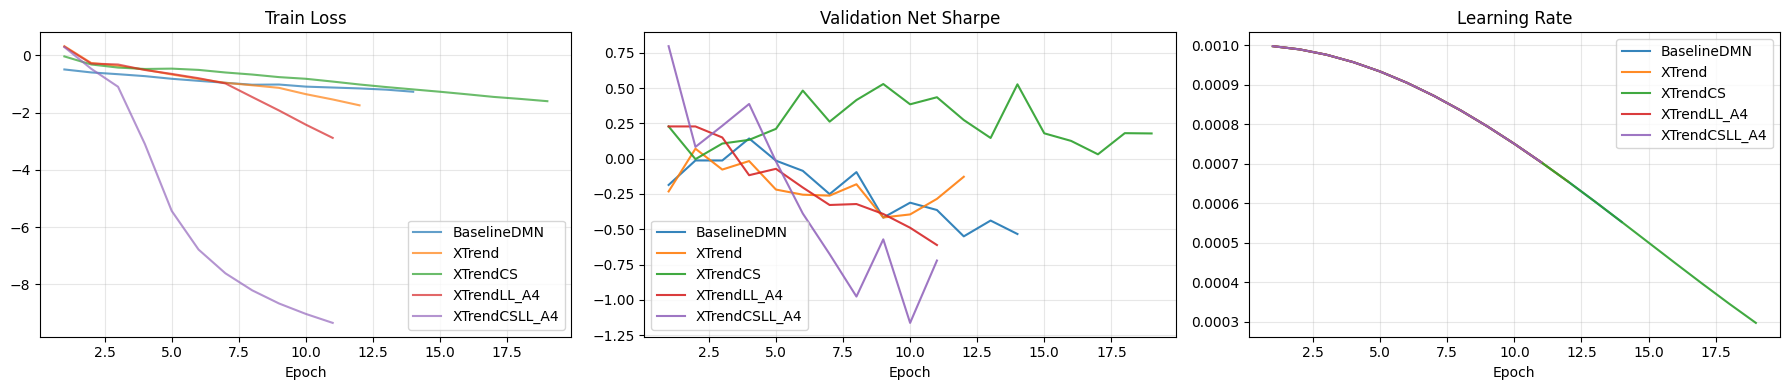

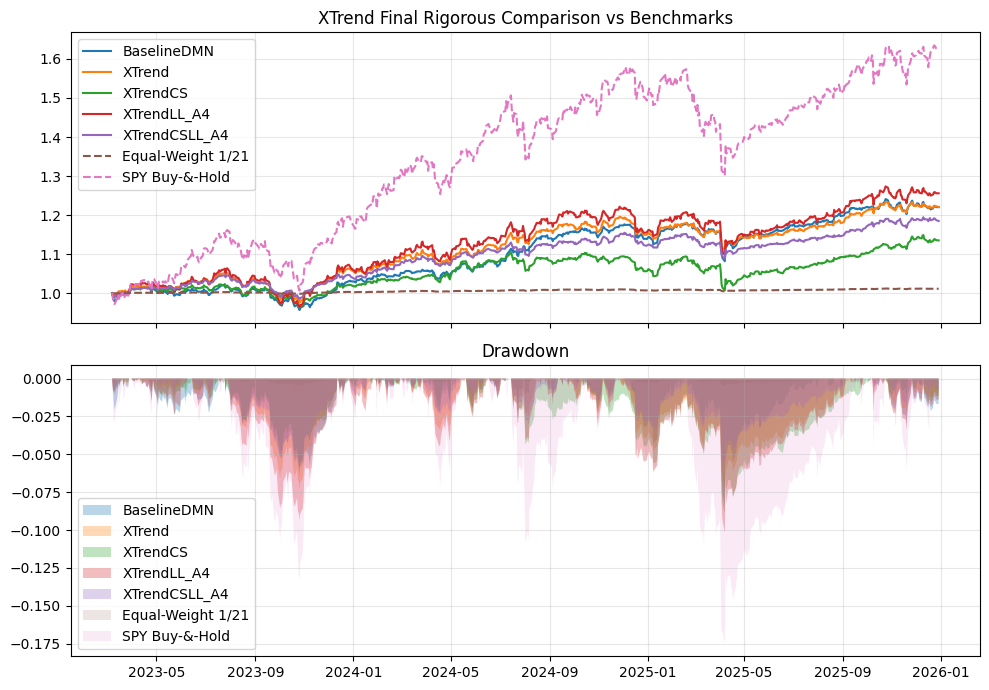

                   gross_ann_return  gross_ann_vol  gross_sharpe  gross_max_dd  gross_calmar  gross_hit_rate  gross_days  net_ann_return  net_ann_vol  net_sharpe  net_max_dd  net_calmar  net_hit_rate  net_days  avg_turnover
model                                                                                                                                                                                                                          
BaselineDMN                  0.0930         0.0681        1.3392       -0.0804        1.1557          0.5615         707          0.0736       0.0681      1.0768     -0.0830      0.8867        0.5431       707        0.1421
XTrend                       0.0739         0.0630        1.1633       -0.0729        1.0143          0.5431         707          0.0737       0.0630      1.1605     -0.0729      1.0117        0.5431       707        0.0014
XTrendCS                     0.0527         0.0629        0.8480       -0.0856        0.6149          0.

In [ ]:
%%time
# -- Run ablation + summarize + save --------------------------------------
ablation_results = {}
for spec in MODEL_SPECS:
    ablation_results[spec['name']] = train_one_model(spec)

summary_df = pd.DataFrame([ablation_results[spec['name']]['summary'] for spec in MODEL_SPECS])
summary_df = summary_df.sort_values('model').reset_index(drop=True)

display_cols = [
    'model', 'hidden_dim', 'num_context', 'params_total', 'train_seconds', 'best_epoch',
    'best_val_sharpe', 'best_val_sharpe_gross', 'best_val_mdd', 'test_gross_sharpe',
    'test_net_sharpe', 'net_sharpe', 'avg_turnover',
]
display(summary_df[display_cols].style.format({
    'params_total': '{:,.0f}',
    'train_seconds': '{:.1f}',
    'best_val_sharpe': '{:.4f}',
    'best_val_sharpe_gross': '{:.4f}',
    'best_val_mdd': '{:.4f}',
    'test_gross_sharpe': '{:.4f}',
    'test_net_sharpe': '{:.4f}',
    'net_sharpe': '{:.4f}',
    'avg_turnover': '{:.4f}',
}))

best_val_model = summary_df.loc[summary_df['best_val_sharpe'].idxmax(), 'model']
best_test_model = summary_df.loc[summary_df['test_net_sharpe'].idxmax(), 'model']
print(f'Recommended by validation net Sharpe: {best_val_model}')
print(f'Best by test net Sharpe:              {best_test_model}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for spec in MODEL_SPECS:
    model_name = spec['name']
    hist = ablation_results[model_name]['history']
    axes[0].plot(hist['epoch'], hist['train_loss'], alpha=0.7, label=model_name)
    axes[1].plot(hist['epoch'], hist['val_sharpe'], alpha=0.9, label=model_name)
    axes[2].plot(hist['epoch'], hist['lr'], alpha=0.9, label=model_name)

axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title('Validation Net Sharpe')
axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()
training_fig = fig

bench_source = ablation_results[MODEL_SPECS[0]['name']]['test_results']['pred_df']
bench = build_benchmarks(bench_source)
model_results = [ablation_results[spec['name']]['backtest'] for spec in MODEL_SPECS]
fig = compare_equity(model_results, bench, title='XTrend Final Rigorous Comparison vs Benchmarks')
plt.show()
comparison_df = print_comparison(model_results + bench)
equity_fig = fig

OUT = Path('/content/drive/MyDrive/results_xtrend_final_rigorous_ablation')
OUT.mkdir(parents=True, exist_ok=True)

summary_df.to_csv(OUT / 'ablation_summary.csv', index=False)
comparison_df.to_csv(OUT / 'comparison_table.csv')

for spec in MODEL_SPECS:
    model_name = spec['name']
    run = ablation_results[model_name]
    stem = model_name.lower()
    torch.save(run['state_dict'], OUT / f'{stem}.pt')
    run['history'].to_csv(OUT / f'{stem}_history.csv', index=False)
    run['test_results']['pred_df'].to_csv(OUT / f'{stem}_predictions.csv', index=False)

training_fig.savefig(OUT / 'ablation_training_curves.png', dpi=150, bbox_inches='tight')
plt.close(training_fig)

equity_fig.savefig(OUT / 'ablation_equity_comparison.png', dpi=150, bbox_inches='tight')
plt.close(equity_fig)

print(f'Saved to {OUT}:')

